In [4]:
# This file examines the DRT response of the subject along with the signalOn event

import torch 
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
import random
import numpy as np
import pathlib
import imageio
import scipy.io
import glob
import csv
import joblib
import math as math
import pandas as pd
from PIL import Image
import eeglib.features as ef
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import plotly.graph_objects as go
import imblearn
from plotly.subplots import make_subplots
from scipy.signal import butter, lfilter
from scipy.signal import freqz
from scipy.stats import norm, kurtosis, entropy, variation, skew
from sklearn.model_selection import train_test_split
from sklearn import metrics
from scipy.stats import variation, spearmanr, kendalltau
from sklearn.decomposition import FastICA
from sklearn.svm import SVC
from sklearn.metrics import plot_roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import shuffle
from sklearn.metrics import f1_score
from tsmoothie.smoother import *

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

# Save the trained models
svc = SVC(kernel="linear", probability=True, random_state=40)
rfc = RandomForestClassifier(random_state=10, max_depth=3)
rf_clf = "rf_clf.joblib"
svm_clf = "svm_clf.joblib"

# Load the saved models
rf_classifier = joblib.load(rf_clf)
svm_classifier = joblib.load(svm_clf)

In [5]:
# PREPROCESSING of SIGNALS
samp_rate_EEG = 500 
samp_rate_SIM = 60
subject_list = ["139"]
signal_list = {}
for i in range(0, len(subject_list)):
    root_dir = "./Subjects/S0" + subject_list[i] + "/"

    # Add EEG signals
    EEG_1 = scipy.io.loadmat(root_dir + "EEG_S0" + subject_list[i] + "_1")
    EEG_2 = scipy.io.loadmat(root_dir + "EEG_S0" + subject_list[i] + "_2")
    EEG1 = EEG_1.get('rawEEG')
    EEG2 = EEG_2.get('rawEEG')
    
    # Sample rate and desired cutoff frequencies (in Hz).
    lowcut = 0.1; highcut = 60.0 
    for ind in range(1, len(EEG1[:, 1])):
        EEG1_part = EEG1[ind, :]
        EEG2_part = EEG2[ind, :]
        EEG1[ind, :] = butter_bandpass_filter(EEG1_part, lowcut, highcut, samp_rate_EEG, order=4)
        EEG2[ind, :] = butter_bandpass_filter(EEG2_part, lowcut, highcut, samp_rate_EEG, order=4)

    signal_list["EEG_S0" + subject_list[i] + "_1"] = EEG1
    signal_list["EEG_S0" + subject_list[i] + "_2"] = EEG2

    # Add event times
    event_times_1 = scipy.io.loadmat(root_dir + "EventTimes_S0" + subject_list[i] + "_1")
    event_times_2 = scipy.io.loadmat(root_dir + "EventTimes_S0" + subject_list[i] + "_2")
    event_desc1 = event_times_1.get('EventDiscription'); event_desc2 = event_times_2.get('EventDiscription')
    event_time1 = event_times_1.get('EventTime'); event_time2 = event_times_2.get('EventTime')
    signal_list["EventDesc_S0" + subject_list[i] + "_1"] = event_desc1; signal_list["EventDesc_S0" + subject_list[i] + "_2"] = event_desc2
    signal_list["EventTime_S0" + subject_list[i] + "_1"] = event_time1; signal_list["EventTime_S0" + subject_list[i] + "_2"] = event_time1

    # Add SIMlsl data for lights-on info
    SIMlsl_1 = scipy.io.loadmat(root_dir + "SIMlsl_S0" + subject_list[i] + "_1")
    SIMlsl_2 = scipy.io.loadmat(root_dir + "SIMlsl_S0" + subject_list[i] + "_2")
    SIMlsl1 = SIMlsl_1.get('SIM_lsl'); SIMlsl2 = SIMlsl_2.get('SIM_lsl'); 
    brake_angle_1 = SIMlsl1[3, :]; brake_angle_2 = SIMlsl2[3, :] 
    brake_lights_on_1 = SIMlsl1[15, :]; brake_lights_on_2 = SIMlsl2[15, :]
    lights_on_time_1 = SIMlsl1[0, :]; lights_on_time_2 = SIMlsl2[0, :]; 
    DRT_onset_time_1 = SIMlsl1[8, :]; DRT_onset_time_2 = SIMlsl2[8, :]; 
    DRT_resp_time_1 = SIMlsl1[9, :]; DRT_resp_time_2 = SIMlsl2[9, :]; 
    signal_list["Brake_Angle_S0" + subject_list[i] + "_1"] = brake_angle_1; signal_list["Brake_Angle_S0" + subject_list[i] + "_2"] = brake_angle_1
    signal_list["BrakeLightsOn_S0" + subject_list[i] + "_1"] = brake_lights_on_1; signal_list["BrakeLightsOn_S0" + subject_list[i] + "_2"] = brake_lights_on_2
    signal_list["BrakeLightsOnTime_S0" + subject_list[i] + "_1"] = lights_on_time_1; signal_list["BrakeLightsOnTime_S0" + subject_list[i] + "_2"] = lights_on_time_2
    signal_list["DRTOnsetTime_S0" + subject_list[i] + "_1"] = DRT_onset_time_1; signal_list["DRTOnsetTime_S0" + subject_list[i] + "_2"] = DRT_onset_time_2;
    signal_list["DRTRespTime_S0" + subject_list[i] + "_1"] = DRT_resp_time_1; signal_list["DRTRespTime_S0" + subject_list[i] + "_2"] = DRT_resp_time_2;
    
    # Add blink info -- in blinkVarNames, the second, third, and fourth rows are start_timestamp, duration, and end_timestamp, respectively.
    blinks_1 = scipy.io.loadmat(root_dir + "Blinks_S0" + subject_list[i] + "_1")
    blinks_2 = scipy.io.loadmat(root_dir + "Blinks_S0" + subject_list[i] + "_2")
    blinks1 = blinks_1.get('Blinks'); blinks2 = blinks_2.get('Blinks'); 
    blinkStartTime_1 = blinks1[:, 1]; blinkDuration_1 = blinks1[:, 2]; blinkEndTime_1 = blinks1[:, 3]
    blinkStartTime_2 = blinks2[:, 1]; blinkDuration_2 = blinks2[:, 2]; blinkEndTime_2 = blinks2[:, 3]
    signal_list["BlinkStartTime_S0" + subject_list[i] + "_1"] = blinkStartTime_1; signal_list["BlinkStartTime_S0" + subject_list[i] + "_2"] = blinkStartTime_2
    signal_list["BlinkDuration_S0" + subject_list[i] + "_1"] = blinkDuration_1; signal_list["BlinkDuration_S0" + subject_list[i] + "_2"] = blinkDuration_2
    signal_list["BlinkEndTime_S0" + subject_list[i] + "_1"] = blinkEndTime_1; signal_list["BlinkEndTime_S0" + subject_list[i] + "_2"] = blinkEndTime_2

    # Add saccade and fixation info
    saccfix_1 = scipy.io.loadmat(root_dir + "SaccFix_S0" + subject_list[i] + "_1")
    saccfix_2 = scipy.io.loadmat(root_dir + "SaccFix_S0" + subject_list[i] + "_2")
    saccade1 = saccfix_1.get('SaccData'); saccade2 = saccfix_2.get('SaccData')
    fixation1 = saccfix_1.get('FixData'); fixation2 = saccfix_2.get('FixData')
    saccadeStartTime_1 = saccade1[:, 0]; saccadeStopTime_1 = saccade1[:, 1]; saccadeDuration_1 = saccade1[:, 2]
    saccadeStartTime_2 = saccade2[:, 0]; saccadeStopTime_2 = saccade2[:, 1]; saccadeDuration_2 = saccade2[:, 2]
    fixationStartTime_1 = fixation1[:, 0]; fixationStopTime_1 = fixation1[:, 1]; fixationDuration_1 = fixation1[:, 2]; fixationStartInd_1 = fixation1[:, 7]
    fixationStartTime_2 = fixation2[:, 0]; fixationStopTime_2 = fixation2[:, 1]; fixationDuration_2 = fixation2[:, 2]; fixationStartInd_2 = fixation2[:, 7]
    signal_list["SaccadeStartTime_S0" + subject_list[i] + "_1"] = saccadeStartTime_1; signal_list["SaccadeStartTime_S0" + subject_list[i] + "_2"] = saccadeStartTime_2
    signal_list["SaccadeStopTime_S0" + subject_list[i] + "_1"] = saccadeStopTime_1; signal_list["SaccadeStopTime_S0" + subject_list[i] + "_2"] = saccadeStopTime_2
    signal_list["SaccadeDuration_S0" + subject_list[i] + "_1"] = saccadeDuration_1; signal_list["SaccadeDuration_S0" + subject_list[i] + "_2"] = saccadeDuration_2
    signal_list["FixationStartTime_S0" + subject_list[i] + "_1"] = fixationStartTime_1; signal_list["FixationStartTime_S0" + subject_list[i] + "_2"] = fixationStartTime_2
    signal_list["FixationStopTime_S0" + subject_list[i] + "_1"] = fixationStopTime_1; signal_list["FixationStopTime_S0" + subject_list[i] + "_2"] = fixationStopTime_2
    signal_list["FixationDuration_S0" + subject_list[i] + "_1"] = fixationDuration_1; signal_list["FixationDuration_S0" + subject_list[i] + "_2"] = fixationDuration_2
    # signal_list["FixationStartInd_S0" + subject_list[i] + "_1"] = fixationStartInd_1; signal_list["FixationStartInd_S0" + subject_list[i] + "_2"] = fixationStartInd_2
    
    

In [670]:
# Create the EVENT MATRIX with the following info:
# [Subject_Name, Session_ID, Event_ID, Lights_on_time]
subject_num = len(subject_list)
session_num = 2
channel_num = 8
lights_on_event_num = 6
channel_to_be_checked = 4 # Change it for the related EEG channel
light_on_events_num = subject_num * session_num * lights_on_event_num
event_len = samp_rate_EEG * 1.5 # For ERP analysis, the signal length of each event is fixed to 750 msec
event_EEG_timeframes = np.zeros((light_on_events_num, int(event_len)))
lights_on_events = np.zeros((light_on_events_num, 6))
count = -1
for k in range(len(subject_list)):
    for p in range(1, session_num + 1):
        
        # Take the signals from the dictionary
        if p == 1:
            EEG1 = signal_list["EEG_S0" + subject_list[k] + "_" + str(p)]
            brake_lights_on1 = signal_list["BrakeLightsOn_S0" + subject_list[k] + "_" + str(p)]
            lights_on_time1 = signal_list["BrakeLightsOnTime_S0" + subject_list[k] + "_" + str(p)]
            blink_start_time1 = signal_list["BlinkStartTime_S0" + subject_list[k] + "_" + str(p)]
            blink_stop_time1 = signal_list["BlinkEndTime_S0" + subject_list[k] + "_" + str(p)]
            saccade_start_time1 = signal_list["SaccadeStartTime_S0" + subject_list[k] + "_" + str(p)]
            saccade_stop_time1 = signal_list["SaccadeStopTime_S0" + subject_list[k] + "_" + str(p)]
            saccade_duration1 = signal_list["SaccadeDuration_S0" + subject_list[k] + "_" + str(p)]
            event_desc1 = signal_list["EventDesc_S0" + subject_list[k] + "_" + str(p)]
            EEG = EEG1; brake_lights_on = brake_lights_on1; lights_on_time = lights_on_time1
            saccade_start_time = saccade_start_time1; saccade_stop_time = saccade_stop_time1
            DRT_onset_time1 = signal_list["DRTOnsetTime_S0" + subject_list[k] + "_" + str(p)]
            DRT_response_time1 = signal_list["DRTRespTime_S0" + subject_list[k] + "_" + str(p)]
            saccadeStartTime1 = signal_list["SaccadeStartTime_S0" + subject_list[k] + "_" + str(p)]
            saccadeStopTime1 = signal_list["SaccadeStopTime_S0" + subject_list[k] + "_" + str(p)]
            saccadeDuration1 = signal_list["SaccadeDuration_S0" + subject_list[k] + "_" + str(p)]
            fixationStartTime1 = signal_list["FixationStartTime_S0" + subject_list[k] + "_" + str(p)]
            fixationStopTime1 = signal_list["FixationStopTime_S0" + subject_list[k] + "_" + str(p)]
            fixationDuration1 = signal_list["FixationDuration_S0" + subject_list[k] + "_" + str(p)]
            
            # Calculate the start of the fixations as the EEG indices
            fixStartIndices_1 = [round((i - EEG1[0, 0]) * samp_rate_EEG) for i in fixationStartTime_1]
            fixStopIndices_1 = [round((i - EEG1[0, 0]) * samp_rate_EEG) for i in fixationStopTime_1]
            fixStartIndices1 = []; fixStopIndices1 = [];
            for i in range(0, len(fixStartIndices_1)):
                if ((fixStartIndices_1[i] > 0) & (fixStartIndices_1[i] < len(EEG1[0, :]))):
                    fixStartIndices1.append(fixStartIndices_1[i])
                if ((fixStopIndices_1[i] > 0) & (fixStopIndices_1[i] < len(EEG1[0, :]))):
                    fixStopIndices1.append(fixStopIndices_1[i])
            
        else:
            EEG2 = signal_list["EEG_S0" + subject_list[k] + "_" + str(p)]
            brake_lights_on2 = signal_list["BrakeLightsOn_S0" + subject_list[k] + "_" + str(p)]
            lights_on_time2 = signal_list["BrakeLightsOnTime_S0" + subject_list[k] + "_" + str(p)]
            blink_start_time2 = signal_list["BlinkStartTime_S0" + subject_list[k] + "_" + str(p)]
            blink_stop_time2 = signal_list["BlinkEndTime_S0" + subject_list[k] + "_" + str(p)]
            saccade_start_time2 = signal_list["SaccadeStartTime_S0" + subject_list[k] + "_" + str(p)]
            saccade_stop_time2 = signal_list["SaccadeStopTime_S0" + subject_list[k] + "_" + str(p)]
            saccade_duration2 = signal_list["SaccadeDuration_S0" + subject_list[k] + "_" + str(p)]
            event_desc2 = signal_list["EventDesc_S0" + subject_list[k] + "_" + str(p)]
            EEG = EEG2; brake_lights_on = brake_lights_on2; lights_on_time = lights_on_time2
            saccade_start_time = saccade_start_time2; saccade_stop_time = saccade_stop_time2
            DRT_onset_time2 = signal_list["DRTOnsetTime_S0" + subject_list[k] + "_" + str(p)]
            DRT_response_time2 = signal_list["DRTRespTime_S0" + subject_list[k] + "_" + str(p)]
            saccadeStartTime2 = signal_list["SaccadeStartTime_S0" + subject_list[k] + "_" + str(p)]
            saccadeStopTime2 = signal_list["SaccadeStopTime_S0" + subject_list[k] + "_" + str(p)]
            saccadeDuration2 = signal_list["SaccadeDuration_S0" + subject_list[k] + "_" + str(p)]
            fixationStartTime2 = signal_list["FixationStartTime_S0" + subject_list[k] + "_" + str(p)]
            fixationStopTime2 = signal_list["FixationStopTime_S0" + subject_list[k] + "_" + str(p)]
            fixationDuration2 = signal_list["FixationDuration_S0" + subject_list[k] + "_" + str(p)]
            
            # Calculate the start of the fixations as the EEG indices
            fixStartIndices_2 = [round((i - EEG2[0, 0]) * samp_rate_EEG) for i in fixationStartTime_2]
            fixStopIndices_2 = [round((i - EEG2[0, 0]) * samp_rate_EEG) for i in fixationStopTime_2]
            fixStartIndices2 = []; fixStopIndices2 = [];
            for i in range(0, len(fixStartIndices_2)):
                if ((fixStartIndices_2[i] > 0) & (fixStartIndices_2[i] < len(EEG2[0, :]))):
                    fixStartIndices2.append(fixStartIndices_2[i])
                if ((fixStopIndices_2[i] > 0) & (fixStopIndices_2[i] < len(EEG2[0, :]))):
                    fixStopIndices2.append(fixStopIndices_2[i])
        
        # Take the index of the starting points of the lights on events
        lights_on = []
        start_index_of_lights_on = []
        for i in range(0, len(brake_lights_on)):
            if brake_lights_on[i] == 1:
                lights_on.append(i)
        start_index_of_lights_on.append(lights_on[0])
        for j in range(1, len(lights_on)):
            if lights_on[j] - lights_on[j-1] > 1:
                start_index_of_lights_on.append(lights_on[j])
        start_index_of_lights_on # This value keeps the starting index of the event

        # Then, calculate the starting time of the events
        start_time_of_lights_on = []
        for t in range(0, len(start_index_of_lights_on)):
            start_time_of_lights_on.append(lights_on_time[start_index_of_lights_on[t]])

        time_frames = np.zeros((6, 2))
        indice_num = 0
        for h in range(0, len(start_time_of_lights_on)):
            # This part takes the starting point from the EEG signal corresponding to the related event 
            start_time = start_time_of_lights_on[h]
            diff_start = abs(EEG[0, 0] - start_time)
            for z in range(1, len(EEG[0, :])):
                if abs(EEG[0, z] - start_time) < diff_start:
                    diff_start = abs(EEG[0, z] - start_time)
                    start_indice = z           
            end_indice = start_indice + event_len 
            time_frames[indice_num][0] = start_indice  # starting index of the event in EEG signal
            time_frames[indice_num][1] = end_indice    # ending index of the event in EEG signal
            indice_num += 1

        for r in range(0, len(start_time_of_lights_on)):
            count += 1
            lights_on_events[count, :] = [subject_list[k], p, r+1, start_time_of_lights_on[r], time_frames[r, 0], time_frames[r, 1]]
            # Finally, assign the related EEG signals to the event_EEG_timeframes matrix
            start_ind = int(time_frames[r, 0])
            end_ind = int(time_frames[r, 1])
            event_EEG_timeframes[count, :] = EEG[channel_to_be_checked, start_ind:end_ind]
        
        lights_on_events1 = lights_on_events[0:6, :]
        lights_on_events2 = lights_on_events[6:12, :]
        
blinking_line1 = np.zeros((len(EEG1[channel_to_be_checked, :])))
for i in range(0, len(blink_start_time1)):
    blink_start = round(blink_start_time1[i]*samp_rate_EEG)
    blink_end = round(blink_stop_time1[i]*samp_rate_EEG)
    if (blink_start > 0) & (blink_end < len(EEG[0, :])):
        blinking_line1[blink_start:blink_end] = 0.05
blinking_line2 = np.zeros((len(EEG2[channel_to_be_checked, :])))
for i in range(0, len(blink_start_time2)):
    blink_start = round(blink_start_time2[i]*samp_rate_EEG)
    blink_end = round(blink_stop_time2[i]*samp_rate_EEG)
    if (blink_start > 0) & (blink_end < len(EEG[0, :])):
        blinking_line2[blink_start:blink_end] = 0.05
        
# Blinking data without latency
latency_len = 250
no_latency_blinking_line1 = blinking_line1; no_latency_blinking_line2 = blinking_line2
no_latency_blinking_line1 = np.pad(no_latency_blinking_line1, (latency_len, 0), 'constant')
no_latency_blinking_line1 = no_latency_blinking_line1[0:len(no_latency_blinking_line1)-latency_len]
no_latency_blinking_line2 = np.pad(no_latency_blinking_line2, (latency_len, 0), 'constant')
no_latency_blinking_line2 = no_latency_blinking_line2[0:len(no_latency_blinking_line2)-latency_len] 

In [671]:
# SIGNAL_ON vs PUSH_BUTTON EVENTS

channel_to_be_checked = 4
event_length = samp_rate_EEG * 3
if event_desc1[:, 1][0] == 1:
    session = 1
else:
    session = 2

if session == 1:
    secs = len(EEG1[0, :]) / samp_rate_EEG
    samp_DRT = len(DRT_onset_time1) / secs
    DRT_onset_time = DRT_onset_time1
    DRT_response_time = DRT_response_time1
    no_latency_blinking_line = no_latency_blinking_line1
    fixStartIndices = fixStartIndices1
    fixStopIndices = fixStopIndices1
else:
    secs = len(EEG2[0, :]) / samp_rate_EEG
    samp_DRT = len(DRT_onset_time2) / secs
    DRT_onset_time = DRT_onset_time2
    DRT_response_time = DRT_response_time2
    no_latency_blinking_line = no_latency_blinking_line2
    fixStartIndices = fixStartIndices2
    fixStopIndices = fixStopIndices2
    
%run -i 'eventTimes.py'
# TAKE VALUES OF SIGNAL_ON EVENTS IN EEG INDEX
onsetTime_onEEG, start_time_of_onsetTime_, end_time_of_onsetTime_ = take_onset_times(DRT_onset_time, EEG, samp_DRT, samp_rate_EEG)
    
# TAKE VALUES OF PUSH_BUTTON EVENTS IN EEG INDEX
responseTime_onEEG, start_time_of_responseTime_, end_time_of_responseTime_ = take_response_times(DRT_response_time, EEG, samp_DRT, samp_rate_EEG)
session

2

In [489]:
# fixationStartTime_1[-10:-1], fixationStopTime_1[-10:-1], EEG1[0, -10:-1]
fixationStartTime_1[0:10], fixationStopTime_1[0:10], fixationDuration_1[0:10], EEG1[0, 0:10]

# Calculate fixation counts per second
# Use window size of 200 ms with sliding windoow size os 100 ms
sliding_size = samp_rate_EEG / 5
window_size = sliding_size * 2
num_windows = round(len(EEG[0, :])/sliding_size)
fixCounts = []
count_fixStart = 0; fixCountCurrent = 0
for i in range(0, num_windows-6):
    win_start = i * sliding_size
    win_end = win_start + window_size
    while (fixStartIndices[count_fixStart] > win_start) & (fixStartIndices[count_fixStart] < win_end):
        fixCountCurrent += 1
        count_fixStart += 1
    fixCounts.append(fixCountCurrent)
    fixCountCurrent = 0

In [672]:
# Take the index numbers of signal trigger events which include the response signals
count = 0
index_with_responses = []
index_without_responses = []
for i in range(1, len(start_time_of_onsetTime_)):
    if (start_time_of_responseTime_[count] > start_time_of_onsetTime_[i-1]) & (start_time_of_responseTime_[count] < start_time_of_onsetTime_[i]):
        index_with_responses.append(i-1)
        count += 1
    else:
        index_without_responses.append(i-1)
    if (i == len(start_time_of_onsetTime_)-1) & (start_time_of_responseTime_[-1] > start_time_of_onsetTime_[-1]):
        index_with_responses.append(i)
# for t in index_with_responses:
#     print(t)

In [673]:
mean_fixation_with_responses = np.zeros((len(index_with_responses), 9))
mean_fixation_without_responses = np.zeros((len(index_without_responses), 9))
ind = 0
for t in index_with_responses:
    # Calculate fixation counts per second
    # Use sliding window of 200 ms
    sliding_size = samp_rate_EEG / 10
    window_size = sliding_size * 2
    event_win_size = 500
    num_windows = round(event_win_size/sliding_size)
    fixCounts = []
    fixCountCurrent = 0
    for i in range(0, num_windows-1):
        win_start = int(start_time_of_onsetTime_[t] + i * sliding_size)
        win_end = int(win_start + window_size)
        # print(win_start, win_end)
        for j in range(0, len(fixStartIndices)):
            if (fixStartIndices[j] > win_start) & (fixStartIndices[j] < win_end):
                fixCountCurrent += 1
        fixCounts.append(fixCountCurrent)
        fixCountCurrent = 0
    fixCounts
    mean_fixation_with_responses[ind, :] = fixCounts
    ind += 1
mean_fixations_with_responses = []
for t in range(0, len(mean_fixation_with_responses[0, :])):
    mean_fixations_with_responses.append(np.mean(mean_fixation_with_responses[:, t]))
mean_fixations_with_responses

[0.6041666666666666,
 0.4791666666666667,
 0.6875,
 0.75,
 0.7083333333333334,
 0.6458333333333334,
 0.5208333333333334,
 0.5416666666666666,
 0.7916666666666666]

In [674]:
mean_fixation_with_responses = np.zeros((len(index_with_responses), 9))
mean_fixation_without_responses = np.zeros((len(index_without_responses), 9))
ind = 0
for t in index_without_responses:
    # Calculate fixation counts per second
    # Use sliding window of 200 ms
    sliding_size = samp_rate_EEG / 10
    window_size = sliding_size * 2
    event_win_size = 500
    num_windows = round(event_win_size/sliding_size)
    fixCounts = []
    fixCountCurrent = 0
    for i in range(0, num_windows-1):
        win_start = int(start_time_of_onsetTime_[t] + i * sliding_size)
        win_end = int(win_start + window_size)
        # print(win_start, win_end)
        for j in range(0, len(fixStartIndices)):
            if (fixStartIndices[j] > win_start) & (fixStartIndices[j] < win_end):
                fixCountCurrent += 1
        fixCounts.append(fixCountCurrent)
        fixCountCurrent = 0
    fixCounts
    mean_fixation_without_responses[ind, :] = fixCounts
    ind += 1
mean_fixations_without_responses = []
for t in range(0, len(mean_fixation_without_responses[0, :])):
    mean_fixations_without_responses.append(np.mean(mean_fixation_without_responses[:, t]))
mean_fixations_with_responses

[0.6041666666666666,
 0.4791666666666667,
 0.6875,
 0.75,
 0.7083333333333334,
 0.6458333333333334,
 0.5208333333333334,
 0.5416666666666666,
 0.7916666666666666]

291844 294844


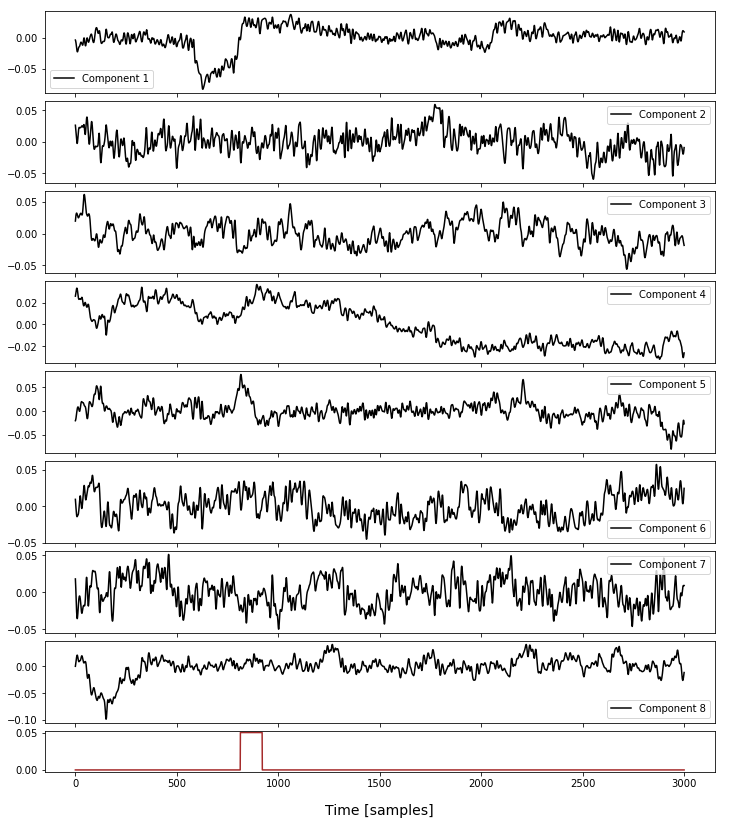

In [498]:
starting_point = int(start_time_of_onsetTime_[n])
ending_point_of_event = int(end_time_of_onsetTime_[n])
ending_point = ending_point_of_event + event_length
print(starting_point, ending_point)
y_ = EEG[channel_to_be_checked, starting_point:ending_point]
x = np.linspace(0, len(y_)/samp_rate_EEG, len(y_))

get_ipython().run_line_magic('run', "-i 'calculate_ICA.py'")
blink_part = no_latency_blinking_line[starting_point:ending_point] # (**)
components, EEG_tr, ica = apply_ICA(EEG, starting_point, ending_point)
visualize_ICA(components, blink_part)


In [ ]:
components[:, 4] = 0

restored = ica.inverse_transform(components)
y_rest = restored[:, channel_to_be_checked-1]

get_ipython().run_line_magic('run', "-i 'apply_Kalman.py'")
smoother = apply_Kalman_Smoother(y_rest)
visualize_Smoothed_Signal(smoother=smoother, no_latency_blinking_line=no_latency_blinking_line, starting_point=starting_point, ending_point=starting_point+700, fix_counts=fixCounts)